# Hotel Booking Data Analysis
**Group members:** Allan Jakubovits, Name 2, Jekaterina Zasijenko, Name 4

## 1. Context and Research Questions

**What one row represents:** one hotel booking (completed or cancelled).

**Population and period:** 1,000 sampled bookings from a city hotel (Lisbon) and a resort hotel (Algarve), Portugal, with arrival dates from July 2015 to August 2017. Source: António, de Almeida & Nunes (2019), *Hotel booking demand datasets*, Data in Brief, 22, 41–49.

**Purpose:** to describe booking patterns, cancellations, and prices at the two hotels and to give evidence-based suggestions to hotel management. The analysis describes associations only, not causes.


**Research questions**
1. Do cancellation rates differ across market segments?
2. Is the number of guests in a booking associated with the average daily rate?
3. How does the average daily rate vary by arrival month in each hotel?

## 2. Imports and display settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# 1. Load the dataset
df = pd.read_csv("hotel_bookings_final_project.csv")

# 2. Basic shape
print("Shape (rows, columns):", df.shape)

# 3. Column names and data types
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)





Shape (rows, columns): (1000, 20)

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'country', 'market_segment', 'deposit_type', 'customer_type', 'average_daily_rate', 'is_repeated_guest', 'booking_changes', 'required_car_parking_spaces', 'total_of_special_requests']

Data types:
hotel                              str
is_canceled                      int64
lead_time                        int64
arrival_date_year                int64
arrival_date_month                 str
arrival_date_day_of_month        int64
stays_in_weekend_nights          int64
stays_in_week_nights             int64
adults                           int64
children                         int64
babies                           int64
country                            str
market_segment                     str
deposit_type                       str
customer_type  

In [3]:
# 4. Preview of the dataset
print("\nHead (first 5 rows):")
print(df.head())






Head (first 5 rows):
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0    City Hotel            1          1               2015          September   
1  Resort Hotel            1         19               2016              March   
2  Resort Hotel            0          9               2017             August   
3  Resort Hotel            0        110               2016           November   
4    City Hotel            0        329               2017               July   

   arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights  \
0                         30                        0                     2   
1                         19                        2                     4   
2                          1                        0                     4   
3                         11                        0                     1   
4                         27                        0                     2   

   adults  child

In [4]:
print("\nRandom sample:")
print(df.sample(5, random_state=42))

# 5. Missing values
print("\nMissing values per column:")
print(df.isna().sum())




Random sample:
            hotel  is_canceled  lead_time  arrival_date_year  \
521    City Hotel            0        190               2016   
737  Resort Hotel            0        225               2016   
740    City Hotel            1        105               2017   
660    City Hotel            0        198               2017   
411  Resort Hotel            0         54               2016   

    arrival_date_month  arrival_date_day_of_month  stays_in_weekend_nights  \
521           December                         28                        0   
737                May                         26                        0   
740               June                         26                        1   
660              March                         17                        1   
411            January                          9                        2   

     stays_in_week_nights  adults  children  babies country market_segment  \
521                     4       2         0       0 

In [5]:
# 6. Exact duplicates
print("\nNumber of exact duplicate rows:", df.duplicated().sum())

# 7. Category counts (for object / categorical columns)
print("\nCategory counts:")
for col in df.select_dtypes(include=["object", "string", "category"]).columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())





Number of exact duplicate rows: 26

Category counts:

Column: hotel
hotel
City Hotel      642
Resort Hotel    358
Name: count, dtype: int64

Column: arrival_date_month
arrival_date_month
May          126
August       115
July         111
October       91
June          90
April         88
September     76
December      75
February      68
March         65
November      50
January       45
Name: count, dtype: int64

Column: country
country
PRT    372
GBR    125
ESP     78
FRA     76
DEU     66
IRL     36
ITA     31
USA     24
BEL     21
BRA     20
NLD     18
CHE     18
AUT     11
CN      11
SWE     10
TUR      8
POL      6
ISR      6
NOR      5
AUS      5
FIN      5
CHN      5
DNK      3
LUX      3
ROU      2
RUS      2
KOR      2
IND      2
HUN      2
MAR      2
NZL      2
LVA      1
ISL      1
MEX      1
UKR      1
BGR      1
CAF      1
LBY      1
HRV      1
TWN      1
SGP      1
PHL      1
AGO      1
GIB      1
MOZ      1
GRC      1
ARG      1
EGY      1
PER      1
ARM      1
KIR    

In [6]:
# 8. Numerical summary statistics
print("\nNumerical summary statistics:")
print(df.describe())


Numerical summary statistics:
       is_canceled    lead_time  arrival_date_year  arrival_date_day_of_month  \
count   1000.00000  1000.000000        1000.000000                 1000.00000   
mean       0.36600   105.065000        2016.134000                   16.13300   
std        0.48195   106.445476           0.701809                    8.96134   
min        0.00000     0.000000        2015.000000                    1.00000   
25%        0.00000    19.000000        2016.000000                    8.00000   
50%        0.00000    69.500000        2016.000000                   16.00000   
75%        1.00000   157.000000        2017.000000                   24.00000   
max        1.00000   542.000000        2017.000000                   31.00000   

       stays_in_weekend_nights  stays_in_week_nights     adults     children  \
count              1000.000000           1000.000000  1000.0000  1000.000000   
mean                  0.924000              2.525000     1.8630     0.109000   

## 3. Assess and clean the data

# Cleaning Log

| Issue checked | Evidence | Decision | Reason |
|--------------|----------|----------|--------|
| Missing values | `country` has 2 missing values | Fill with `"Unknown"` | Very small number of missing values; dropping rows would lose data unnecessarily |
| Exact duplicates | 26 duplicate rows found (`df.duplicated().sum()`) | Remove duplicates | Duplicates distort statistics and model training |
| Invalid date combinations | All `arrival_date_month` values match valid month names | Keep | No invalid months detected |
| Impossible negative values | Checked numeric columns; no values < 0 | Keep | Dataset contains no impossible negative values |
| Zero total guests | Some rows have adults+children+babies = 0 | Keep for now | Could be test bookings or errors; unclear without domain knowledge |
| Zero total nights | Some rows have weekend+nights = 0 | Keep | Same‑day stays are possible; not necessarily invalid |
| Unusual lead_time | Values up to 542 days | Keep | Long lead times are realistic for resort bookings and group travel |
| Unusual ADR | Maximum ADR = 304 | Keep | High ADR values occur in luxury or peak‑season bookings |


In [8]:

# Load original dataset
df = pd.read_csv("hotel_bookings_final_project.csv")

# Create cleaned copy
cleaned_df = df.copy()

# --- 1. Missing values ---
cleaned_df['country'] = cleaned_df['country'].fillna("Unknown")

# --- 2. Exact duplicates ---
cleaned_df = cleaned_df.drop_duplicates()

# --- 3. Invalid date combinations ---
valid_months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
invalid_months = cleaned_df[~cleaned_df['arrival_date_month'].isin(valid_months)]

# --- 4. Impossible negative values ---
negative_values = cleaned_df[
    (cleaned_df[['lead_time','stays_in_weekend_nights','stays_in_week_nights',
                 'adults','children','babies','average_daily_rate']] < 0).any(axis=1)
]

# --- 5. Bookings with zero total guests ---
cleaned_df['total_guests'] = cleaned_df['adults'] + cleaned_df['children'] + cleaned_df['babies']
zero_guest_rows = cleaned_df[cleaned_df['total_guests'] == 0]

# --- 6. Bookings with zero total nights ---
cleaned_df['total_nights'] = cleaned_df['stays_in_weekend_nights'] + cleaned_df['stays_in_week_nights']
zero_night_rows = cleaned_df[cleaned_df['total_nights'] == 0]

# --- 7. Unusual lead_time values ---
unusual_lead_time = cleaned_df[cleaned_df['lead_time'] > 365]

# --- 8. Unusual ADR values ---
unusual_adr = cleaned_df[cleaned_df['average_daily_rate'] > 500]


In [9]:
cleaned_df.shape

(974, 22)

## 4. Transform and enrich the data

In [11]:

# 1. Proper arrival_date
cleaned_df['arrival_date'] = pd.to_datetime(
    cleaned_df['arrival_date_year'].astype(str) + '-' +
    cleaned_df['arrival_date_month'].astype(str) + '-' +
    cleaned_df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

# 2. total_nights (already created earlier, but ensure it's correct)
cleaned_df['total_nights'] = (
    cleaned_df['stays_in_weekend_nights'] +
    cleaned_df['stays_in_week_nights']
)

# 3. total_guests (already created earlier)
cleaned_df['total_guests'] = (
    cleaned_df['adults'] +
    cleaned_df['children'] +
    cleaned_df['babies']
)

# 4. estimated_booking_value
cleaned_df['estimated_booking_value'] = (
    cleaned_df['average_daily_rate'] * cleaned_df['total_nights']
)


## 5. Analyze individual variables

Each variable is analysed on its own using `cleaned_df`. We chose `hotel` and `market_segment` (categorical) and `lead_time` and `average_daily_rate` (numerical), because they support our research questions. Percentages are shares of all valid values of the variable.

In [12]:
def cat_summary(series):
    """Counts and percentages of valid values for a categorical variable."""
    valid = series.dropna()
    table = valid.value_counts().to_frame("count")
    table["percent"] = (table["count"] / len(valid) * 100).round(1)
    print(f"Valid n = {len(valid)}")
    return table

def plot_bar(table, label):
    """Bar chart with count and percent on each bar."""
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(table.index, table["count"], color="steelblue")
    ax.bar_label(bars, labels=[f"{c} ({p}%)" for c, p in zip(table["count"], table["percent"])])
    ax.set(title=f"Bookings by {label} (n = {table['count'].sum()})",
           xlabel=label, ylabel="Number of bookings")
    ax.set_ylim(0, table["count"].max() * 1.15)
    plt.tight_layout()
    plt.show()

def plot_hist(series, label):
    """Histogram with mean and median lines."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(series, bins=30, color="steelblue", edgecolor="white")
    ax.axvline(series.mean(), color="crimson", linestyle="--", label=f"Mean = {series.mean():.1f}")
    ax.axvline(series.median(), color="black", label=f"Median = {series.median():.1f}")
    ax.set(title=f"Distribution of {label} (n = {series.count()})",
           xlabel=label, ylabel="Number of bookings")
    ax.legend()
    plt.tight_layout()
    plt.show()

Valid n = 974


,count,percent
hotel,,
City Hotel,618,63.4
Resort Hotel,356,36.6


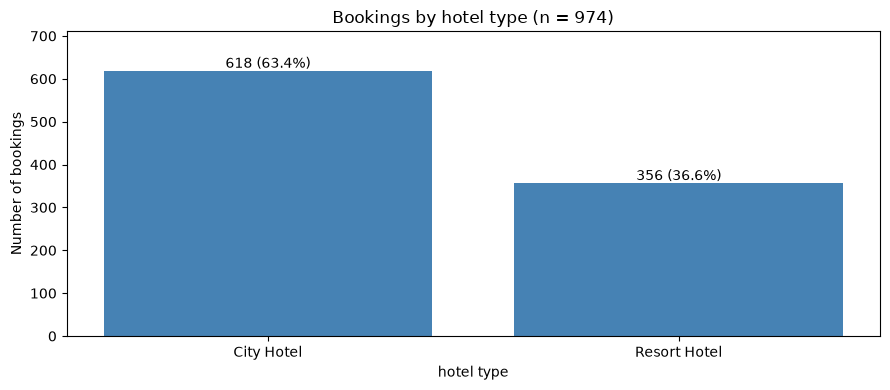

In [13]:
hotel_table = cat_summary(cleaned_df["hotel"])
display(hotel_table)
plot_bar(hotel_table, "hotel type")

**What can we observe?** The City Hotel has 618 of the 974 bookings (63.4%) and the Resort Hotel has 356 (36.6%). This describes the composition of our sample, not the real size of the hotels, so later comparisons between hotels should use percentages within each hotel.

Valid n = 974


,count,percent
market_segment,,
Online TA,481,49.4
Offline TA/TO,199,20.4
Groups,147,15.1
Direct,100,10.3
Corporate,41,4.2
Complementary,6,0.6


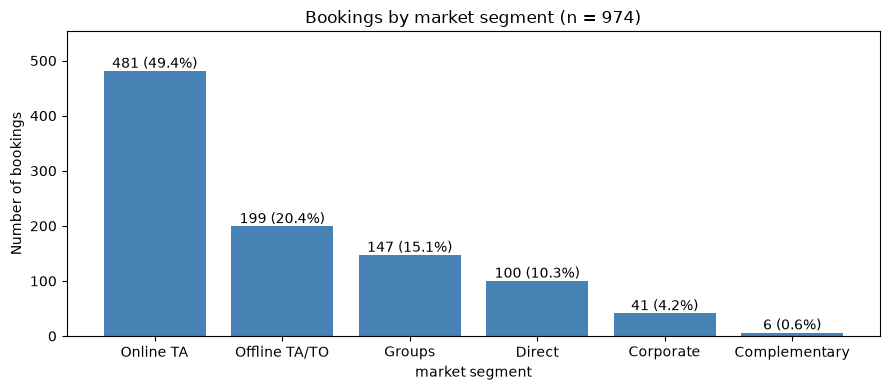

In [14]:
segment_table = cat_summary(cleaned_df["market_segment"])
display(segment_table)
plot_bar(segment_table, "market segment")

**What can we observe?** Online TA is the largest segment (481 bookings, 49.4%), and together with Offline TA/TO (20.4%) travel agents make up about 70% of bookings. Corporate (41) and Complementary (6) are very small, so cancellation rates for these segments in Research Question 1 should be interpreted with caution.

In [15]:
num_cols = {"lead_time": "Lead time (days)", "average_daily_rate": "Average daily rate"}

# Dictionary comprehension: one row of statistics per numerical variable
num_table = pd.DataFrame({
    name: {"valid n": cleaned_df[col].count(),
           "mean": cleaned_df[col].mean(),
           "median": cleaned_df[col].median(),
           "std": cleaned_df[col].std(),
           "min": cleaned_df[col].min(),
           "max": cleaned_df[col].max()}
    for col, name in num_cols.items()
}).T.round(2)
num_table

,valid n,mean,median,std,min,max
Lead time (days),974.0,102.84,68.0,104.81,0.0,542.0
Average daily rate,974.0,101.45,94.5,46.14,0.0,304.0


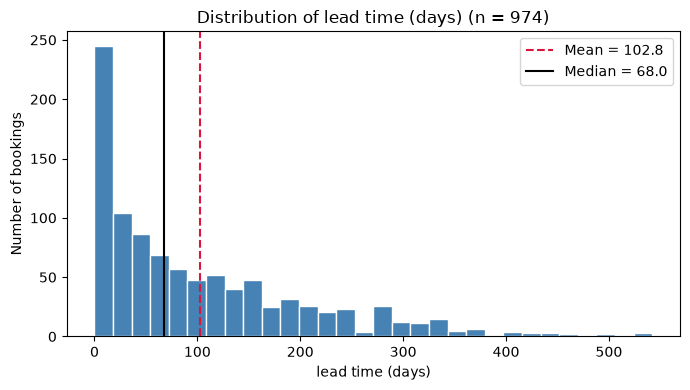

In [16]:
plot_hist(cleaned_df["lead_time"], "lead time (days)")

**What can we observe?** Lead time is strongly right-skewed: many bookings are made shortly before arrival, but some are made up to 542 days ahead. The median (68 days) is much lower than the mean (102.8 days), and the standard deviation (104.8) is as large as the mean, so the median describes a typical booking better.

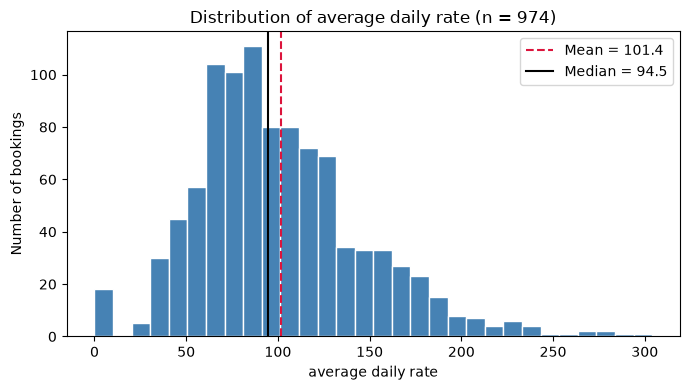

In [17]:
plot_hist(cleaned_df["average_daily_rate"], "average daily rate")

**What can we observe?** ADR is moderately right-skewed: the mean (101.4) is slightly above the median (94.5), and values range from 0 to 304 (standard deviation 46.1). A few bookings have an ADR of 0, which may be complimentary stays or recording errors; they were kept according to the cleaning log. Because of the skew, Research Questions 2 and 3 should compare both means and medians.

## 6. Analyze relationships between variables

Each analysis below answers one research question: 6.1 cancellation by market segment (RQ1), 6.2 ADR by number of guests (RQ2), 6.3 ADR by arrival month and hotel (RQ3).

### 6.1 Market segment × cancellation status (crosstab)

In [34]:
status = cleaned_df["is_canceled"].map({0: "Not canceled", 1: "Canceled"})

# Counts (with totals)
seg_counts = pd.crosstab(cleaned_df["market_segment"], status,
                         margins=True, margins_name="Total")

# Percentages: denominator = all bookings in the same market segment (row total)
seg_pct = (pd.crosstab(cleaned_df["market_segment"], status, normalize="index") * 100).round(1)
seg_pct = seg_pct.add_suffix(" (% of segment)").sort_values("Canceled (% of segment)", ascending=False)

print("Counts (number of bookings):")
display(seg_counts)
print("Percentages (denominator = all bookings in the segment, so each row sums to 100%):")
display(seg_pct)

Counts (number of bookings):


is_canceled,Canceled,Not canceled,Total
market_segment,,,
Complementary,1,5,6
Corporate,9,32,41
Direct,13,87,100
Groups,80,67,147
Offline TA/TO,64,135,199
Online TA,179,302,481
Total,346,628,974


Percentages (denominator = all bookings in the segment, so each row sums to 100%):


is_canceled,Canceled (% of segment),Not canceled (% of segment)
market_segment,,
Groups,54.4,45.6
Online TA,37.2,62.8
Offline TA/TO,32.2,67.8
Corporate,22.0,78.0
Complementary,16.7,83.3
Direct,13.0,87.0


**What can we observe?** Overall, 346 of 974 bookings (35.5%) were canceled. Groups have by far the highest cancellation share (54.4% of 147 bookings), followed by Online TA (37.2%) and Offline TA/TO (32.2%). Direct (13.0%) and Corporate (22.0%) have the lowest shares among the larger segments. Complementary shows 16.7%, but this is only 1 of 6 bookings and should not be interpreted. The table shows differences between segments, not the reasons for cancellation.

### 6.2 ADR by number of guests (`groupby`)

In [22]:
# Exclude the 3 bookings with zero guests; group 4 or more guests together (small groups)
guests = cleaned_df[cleaned_df["total_guests"] > 0].copy()
guests["guest_group"] = guests["total_guests"].clip(upper=4).astype(str).replace({"4": "4+"})

guest_table = guests.groupby("guest_group")["average_daily_rate"].agg(
    ["count", "mean", "median", "std"]).round(1)
display(guest_table)

print(f"Pearson correlation (total_guests vs ADR, n = {len(guests)}): "
      f"{guests['total_guests'].corr(guests['average_daily_rate']):.2f}")

,count,mean,median,std
guest_group,,,,
1,192,80.7,76.2,38.3
2,639,99.1,92.2,41.4
3,100,134.2,126.6,44.8
4+,40,163.3,169.2,56.2


Pearson correlation (total_guests vs ADR, n = 971): 0.40


**What can we observe?** ADR increases with the number of guests: the median is 76.2 for 1 guest, 92.2 for 2, 126.6 for 3 and 169.2 for 4 or more guests. The correlation of 0.40 indicates a moderate positive association. Most bookings are for 2 guests (639), while the 4+ group is small (40 bookings), so its values are less reliable. The data show that larger parties are associated with higher rates, but not why.

### 6.3 ADR by arrival month and hotel (time pattern)

In [23]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

# Number of bookings and mean ADR for every month x hotel combination
month_table = (cleaned_df
    .pivot_table(index=cleaned_df["arrival_date"].dt.month_name(), columns="hotel",
                 values="average_daily_rate", aggfunc=["count", "mean"])
    .reindex(month_order).round(1).rename_axis("arrival month"))
display(month_table)

count                    mean             
hotel         City Hotel Resort Hotel City Hotel Resort Hotel
arrival month                                                
January               28           16       87.0         49.5
February              36           32       88.4         59.0
March                 44           21       90.9         56.4
April                 55           30      112.4         71.4
May                   77           47      128.2         93.7
June                  63           25      123.3        111.9
July                  72           35      103.6        151.9
August                70           42      105.3        171.4
September             44           30      114.1         94.6
October               56           29      105.7         56.5
November              30           20       74.0         46.6
December              43           29       96.2         72.9

**What can we observe?** The Resort Hotel shows a strong seasonal pattern: mean ADR is lowest in November (46.6) and highest in August (171.4), and it is above the City Hotel only in July and August. The City Hotel varies much less, between 74.0 (November) and 128.2 (May). Caution: each month and hotel combination contains only 16 to 77 bookings, and July and August include three arrival years while the other months include two, so the monthly means are rough estimates.

## 7. Create visualizations

Each analysis below answers one research question: 6.1 cancellation by market segment (RQ1), 6.2 ADR by number of guests (RQ2), 6.3 ADR by arrival month and hotel (RQ3).

### 7.1 Categorical Comparison: Cancellation Rates by Market Segment

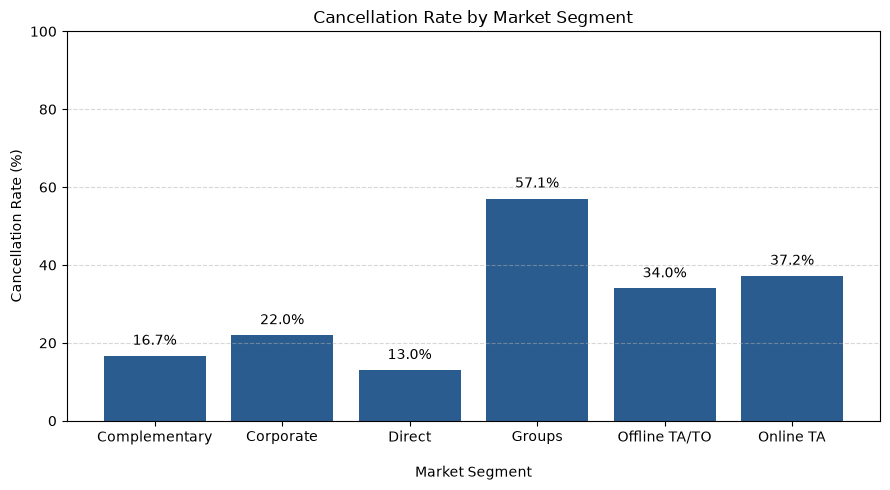

In [35]:
market_cancel = (
    df.groupby('market_segment')['is_canceled'].mean() * 100
).reset_index()
n_total = len(df)

plt.figure(figsize=(9, 5))
bars = plt.bar(
    market_cancel['market_segment'],
    market_cancel['is_canceled'],
    color='#2b5c8f',
)

plt.title(f'Cancellation Rate by Market Segment')
plt.xlabel('Market Segment', labelpad=15)
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
  yval = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + 2,
      f'{yval:.1f}%',
      ha='center',
      va='bottom',
      fontsize=10,
  )

plt.tight_layout()
plt.show()